In [2]:
import os
import pandas as pd
import wave
import numpy as np
import matplotlib.pyplot as plt
import librosa
import shutil
import pickle
import pywt
from scipy.stats import kurtosis
import wav_utils
from skimage.filters import threshold_otsu
from matplotlib.gridspec import GridSpec

In [3]:
def get_mfcc(data, sample_rate, n_mels=128, f_min=50, f_max=1800, winLength = 256, nfft=512, hop=256, numCoeffs = 13):
    mel_spec = librosa.feature.melspectrogram(y=data, sr=sample_rate, n_mels=n_mels, fmin=f_min, fmax=f_max,
                                       win_length = winLength, n_fft=nfft, hop_length=hop)
    
    # Convert to log scale
    log_mel_spec = librosa.power_to_db(mel_spec)

    mfccs = librosa.feature.mfcc(S=log_mel_spec,n_mfcc=numCoeffs,hop_length=hop)

    return mfccs

In [ ]:
dataFolder = "Samples"

n_fft = 4096 

data_files = os.listdir(dataFolder)
data_files.sort()

all_MFCC_std = []
all_MFCC_delta_std = []
all_MFCC_deltadelta_std = []
allSeverity = []


for data_file in data_files:

    #if not a wav file, skip
    if ".wav" not in data_file:
        continue

    # path
    wavFilepath = f"{dataFolder}/{data_file}"

    userName, userTest, userSeverity = wav_utils.getTestInfo(data_file)

    # load data
    raw_audio, sample_rate = librosa.load(path=wavFilepath, sr=4000)

    # Noise reduction method, filter
    filter_lowcut = 80
    filter_highcut = 1800
    filter_order = 8
    filter_btype = "bandpass"  
    filt_audio = wav_utils.filter_denoise(raw_audio, sample_rate, filter_order,
                                    filter_lowcut, filter_highcut, btype=filter_btype)

    raw_audio = raw_audio - np.mean(raw_audio)  # Remove DC
    filt_audio = filt_audio - np.mean(filt_audio)  # Remove DC

    # Normalise and remove DC component in signal
    x = wav_utils.dc_normalise(filt_audio)

    mfcc = get_mfcc(x,sample_rate)
    mfcc_delta = librosa.feature.delta(mfcc,order=1)
    mfcc_deltadelta = librosa.feature.delta(mfcc,order=2)

    all_MFCC_std.append(np.std(mfcc))
    all_MFCC_delta_std.append(np.std(mfcc_delta))
    all_MFCC_deltadelta_std.append(np.std(mfcc_deltadelta))
    allSeverity.append(userSeverity)

    

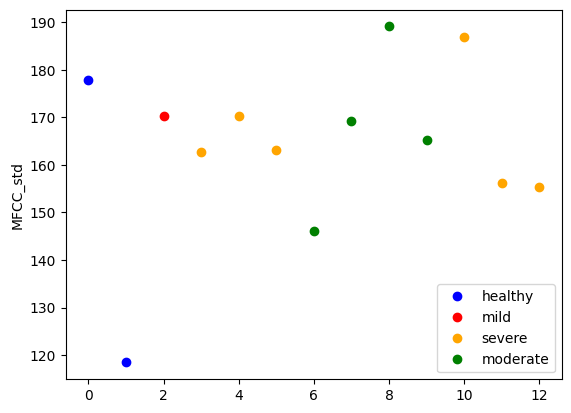

In [37]:
# PLotting standard deviation of MFCCs
category_colors = {
    'healthy': 'blue',
    'mild': 'red',
    'moderate': 'green',
    'severe': 'orange'
}

for idx,(row,cat) in enumerate(zip(all_MFCC_std,allSeverity)):
    plt.plot(idx,row,'o',color=category_colors[cat],label=cat)

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())
plt.ylabel('MFCC_std')

plt.show()

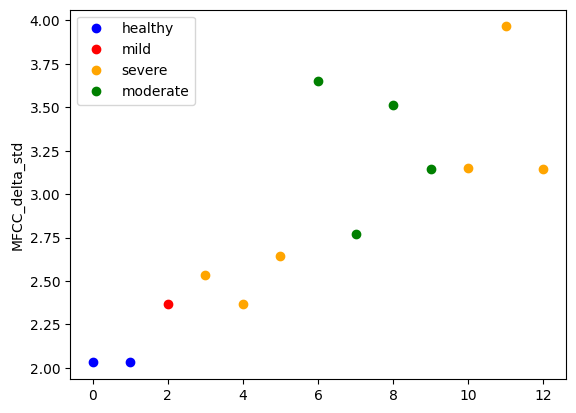

In [38]:
# Plotting standard deviation of MFCC deltas

for idx,(row,cat) in enumerate(zip(all_MFCC_delta_std,allSeverity)):
    plt.plot(idx,row,'o',color=category_colors[cat],label=cat)

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())
plt.ylabel('MFCC_delta_std')

plt.show()

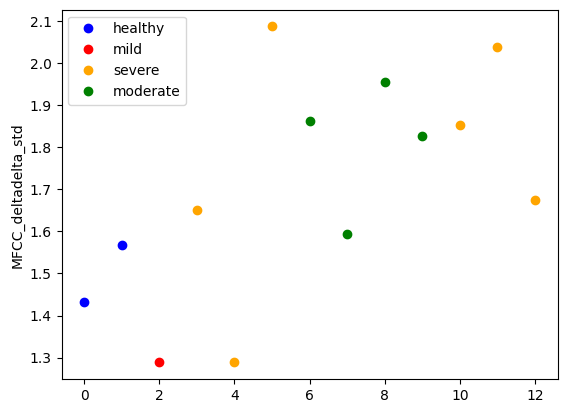

In [39]:
# Plotting standard deviation of MFCC delta deltas

for idx,(row,cat) in enumerate(zip(all_MFCC_deltadelta_std,allSeverity)):
    plt.plot(idx,row,'o',color=category_colors[cat],label=cat)

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())
plt.ylabel('MFCC_deltadelta_std')

plt.show()

In [47]:
def getICBHItestInfo(icbhi_filename):
    
    # Removing file type suffic
    fileStub = str.split(icbhi_filename,'.')[0]

    # Splitting file name by '_' delimitter
    strComponents = str.split(fileStub,'_')

    userName = strComponents[0]
    userTest = strComponents[1]
    

    return userName, userTest

def load_diagnosis_labels(diagnosis_file_loc):
    
    # diagnosis_map = {
    #     "URTI": 1,
    #     "Healthy": 2,
    #     "Asthma": 3,
    #     "COPD": 4,
    #     "LRTI": 5,
    #     "Bronchiectasis": 6,
    #     "Pneumonia": 7,
    #     "Bronchiolitis": 8
    # }
    
    diagnosis_dict = {}
    with open(diagnosis_file_loc, "r") as f:
        for line in f:
            line = line.strip()
            if line:  # Skip empty lines
                subjectID, diagnosis = line.split(",")
                diagnosis_dict[subjectID] = diagnosis
    
    return diagnosis_dict

diagnosis_filepath = "Databases/ICBHI/patient_diagnosis.csv"
diagnosis_dict = load_diagnosis_labels(diagnosis_filepath)

In [48]:
# find posterior (Pl and Pr), single channel (sc) and Litt3200 recordings
dataFolder = "Databases/ICBHI/audio_and_txt_files"

wav_files = [f.name for f in os.scandir(dataFolder) if f.name.endswith('.wav') and ('Pr_sc' in f.name or 'Pl_sc' in f.name)]


In [49]:
all_MFCC_std = []
all_MFCC_delta_std = []
all_MFCC_deltadelta_std = []
allDiagnoses = []


for fileIdx, wav_file in enumerate(wav_files):

    #if not a wav file, skip
    if ".wav" not in wav_file:
        continue

        # path
    wavFilepath = f"{dataFolder}/{wav_file}"

    userName = wav_file[:3]
    diagnosis = diagnosis_dict[userName]
   
    # load data
    raw_audio, sample_rate = librosa.load(path=wavFilepath, sr=4000)

    # Noise reduction method, filter
    filter_lowcut = 80
    filter_highcut = 1800
    filter_order = 8
    filter_btype = "bandpass"  
    filt_audio = wav_utils.filter_denoise(raw_audio, sample_rate, filter_order,
                                    filter_lowcut, filter_highcut, btype=filter_btype)

    raw_audio = raw_audio - np.mean(raw_audio)  # Remove DC
    filt_audio = filt_audio - np.mean(filt_audio)  # Remove DC

    # Normalise and remove DC component in signal
    x = wav_utils.dc_normalise(filt_audio)


    # ***************
    # MFCC analysis
    # ***************
    
    mfcc = get_mfcc(x,sample_rate)
    mfcc_delta = librosa.feature.delta(mfcc,order=1)
    mfcc_deltadelta = librosa.feature.delta(mfcc,order=2)

    all_MFCC_std.append(np.std(mfcc))
    all_MFCC_delta_std.append(np.std(mfcc_delta))
    all_MFCC_deltadelta_std.append(np.std(mfcc_deltadelta))
    allDiagnoses.append(diagnosis)

In [54]:
category_colors = {
    "URTI": 'red',
    "Healthy": 'lightgreen',
    "Asthma": 'blue',
    "COPD": 'orange',
    "LRTI": 'yellow',
    "Bronchiectasis": 'black',
    "Pneumonia": 'pink',
    "Bronchiolitis": 'purple'
}

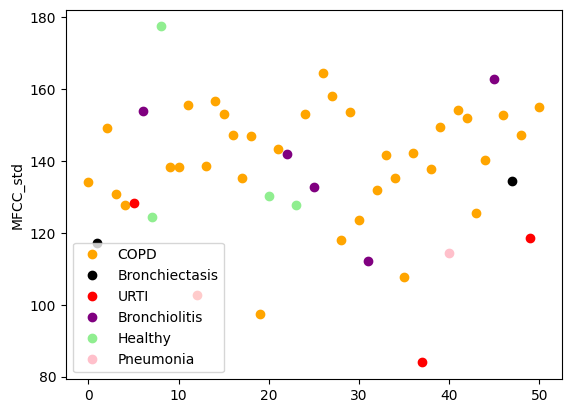

In [55]:
for idx,(row,cat) in enumerate(zip(all_MFCC_std,allDiagnoses)):
    plt.plot(idx,row,'o',color=category_colors[cat],label=cat)

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())
plt.ylabel('MFCC_std')

plt.show()

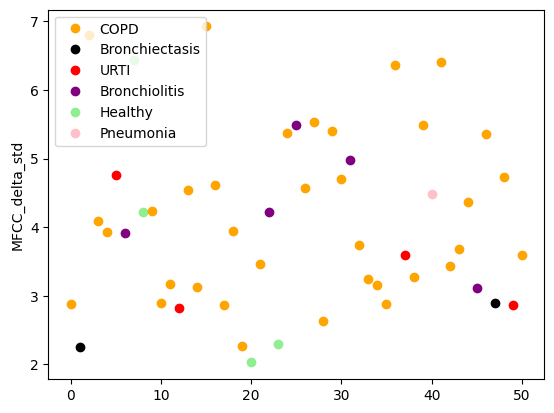

In [56]:
for idx,(row,cat) in enumerate(zip(all_MFCC_delta_std,allDiagnoses)):
    plt.plot(idx,row,'o',color=category_colors[cat],label=cat)

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())
plt.ylabel('MFCC_delta_std')

plt.show()

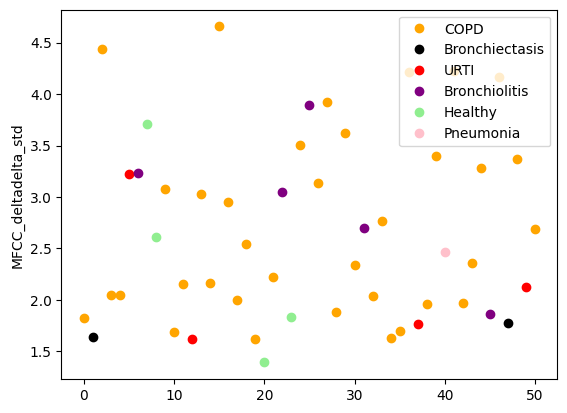

In [57]:
for idx,(row,cat) in enumerate(zip(all_MFCC_deltadelta_std,allDiagnoses)):
    plt.plot(idx,row,'o',color=category_colors[cat],label=cat)

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())
plt.ylabel('MFCC_deltadelta_std')

plt.show()

*************************
MFCC metrics on a windowed basis
*************************

Eko_p000_t01_healthy_pos_U_stance_U_20250228.wav
plotFrac:  0.41528239202657813
312


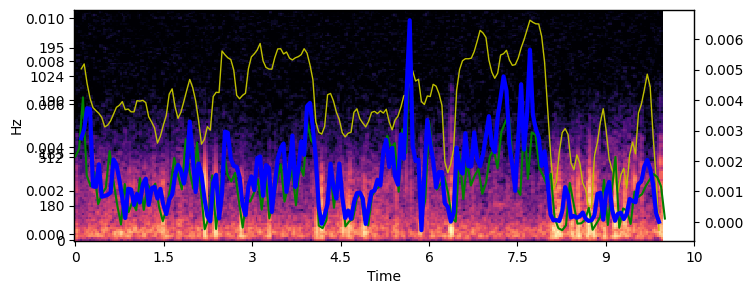

Eko_p000_t02_healthy_pos_U_stance_U_20250228.wav
plotFrac:  0.5016051364365971
313


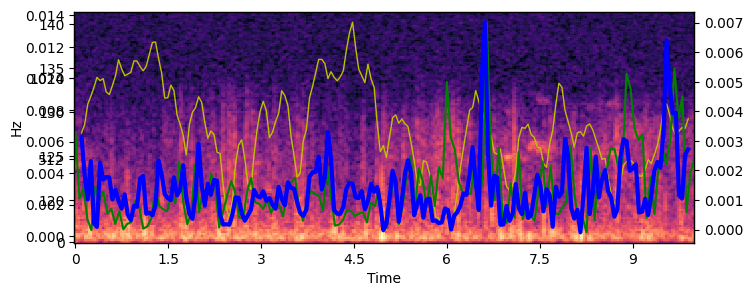

Eko_p001_t01_mild_pos_LLP_stance_SIT_20250214.wav
plotFrac:  0.6666666666666666
312


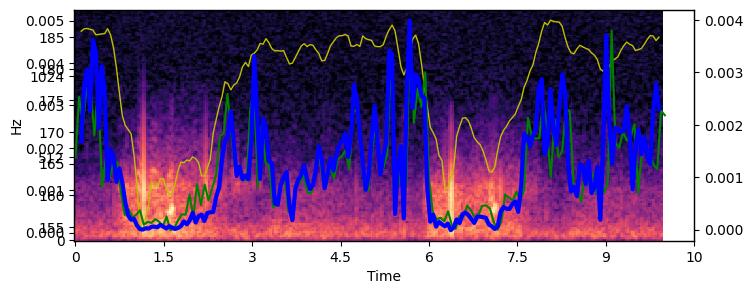

Eko_p002_t01_severe_pos_U_stance_U_20250221.wav
plotFrac:  0.6666666666666666
312


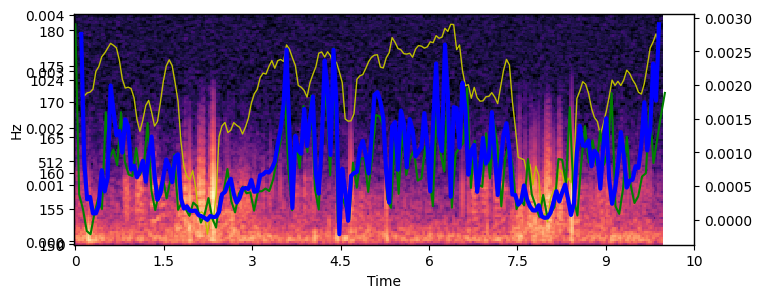

Eko_p002_t02_severe_pos_LLP_stance_SIT_20250214.wav
plotFrac:  0.6666666666666666
312


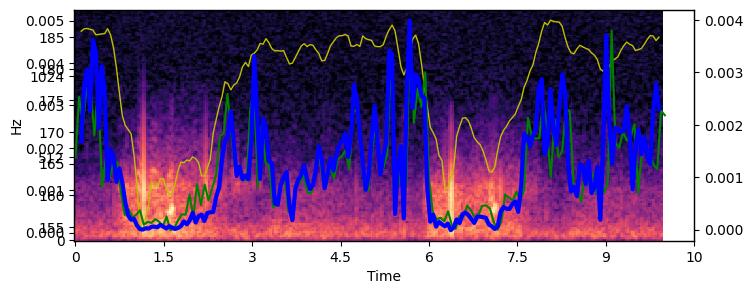

Eko_p002_t03_severe_pos_RLP_stance_U_20250221.wav
plotFrac:  0.6666666666666666
312


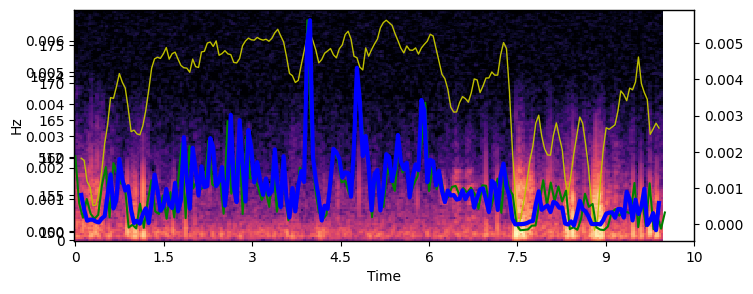

Eko_p003_t01_moderate_pos_LEFT_stance_U_20250227.wav
plotFrac:  0.6666666666666666
312


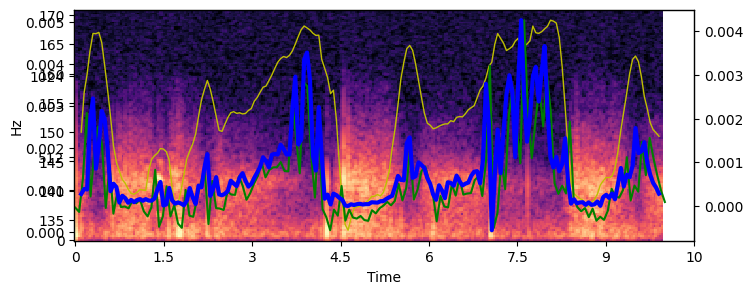

Eko_p003_t02_moderate_pos_RIGHT_stance_U_20250227.wav
plotFrac:  0.16666666666666666
312


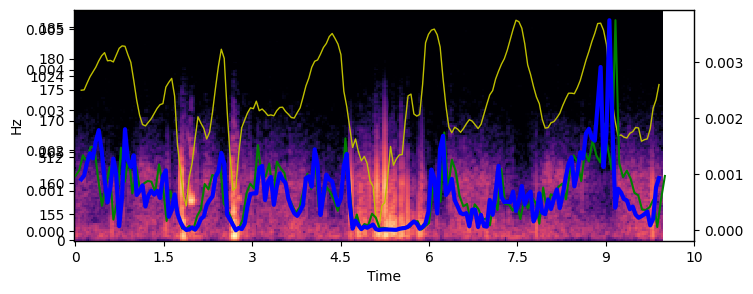

Eko_p004_t01_moderate_pos_U_stance_U_20250228.wav
plotFrac:  0.16666666666666666
312


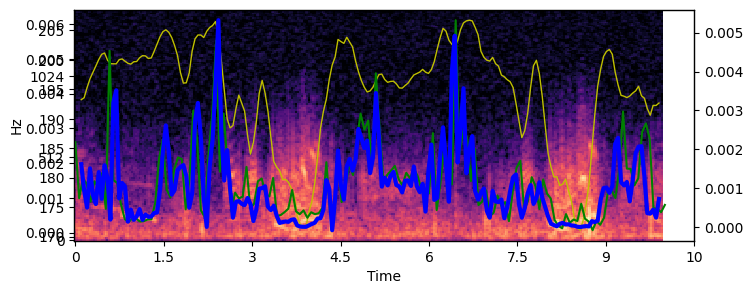

Eko_p004_t02_moderate_pos_U_stance_U_20250228.wav
plotFrac:  0.16666666666666666
312


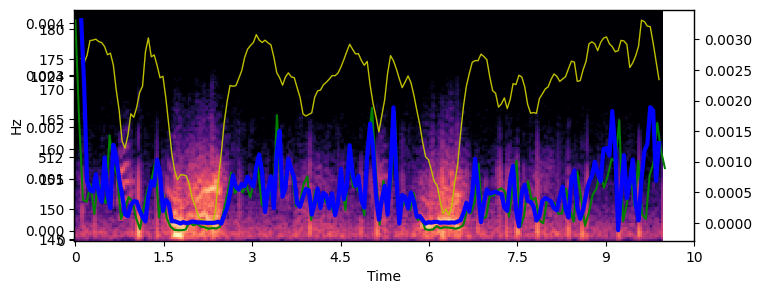

Eko_p005_t01_severe_pos_U_stance_U_20250605.wav
plotFrac:  0.16666666666666666
312


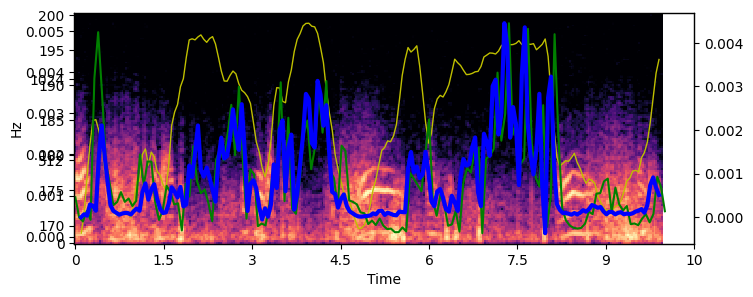

Eko_p005_t02_severe_pos_U_stance_U_20250605.wav
plotFrac:  0.16666666666666666
312


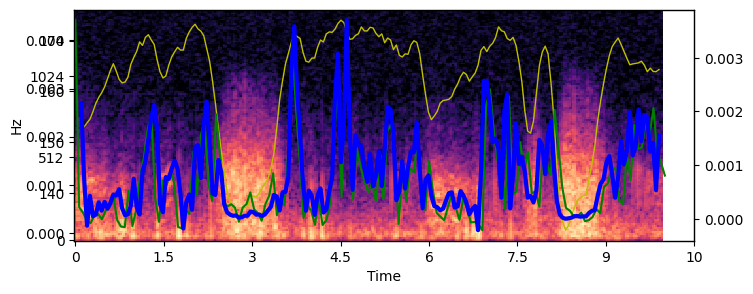

Eko_p006_t01_severe_pos_RLP_stance_SIT_20250604.wav
plotFrac:  0.16666666666666666
312


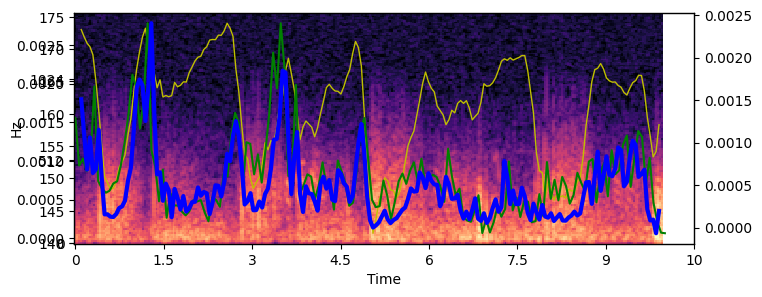

In [170]:
# Applying MFCC analysis on a windowed basis

dataFolder = "Samples"

n_fft = 4096 

data_files = os.listdir(dataFolder)
data_files.sort()
#data_files = ['Eko_p005_t01_severe_pos_U_stance_U_20250605.wav']
#data_files = ['Eko_p000_t01_healthy_pos_U_stance_U_20250228.wav']


for data_file in data_files:

    #if not a wav file, skip
    if ".wav" not in data_file:
        continue
    
    print(data_file)

    # path
    wavFilepath = f"{dataFolder}/{data_file}"

    userName, userTest, userSeverity = wav_utils.getTestInfo(data_file)

    # load data
    raw_audio, sample_rate = librosa.load(path=wavFilepath, sr=4000)

    # Noise reduction method, filter
    filter_lowcut = 80
    filter_highcut = 1800
    filter_order = 8
    filter_btype = "bandpass"  
    filt_audio = wav_utils.filter_denoise(raw_audio, sample_rate, filter_order,
                                    filter_lowcut, filter_highcut, btype=filter_btype)

    raw_audio = raw_audio - np.mean(raw_audio)  # Remove DC
    filt_audio = filt_audio - np.mean(filt_audio)  # Remove DC

    # Normalise and remove DC component in signal
    x = wav_utils.dc_normalise(filt_audio)

    mfcc = get_mfcc(x, sample_rate, n_mels=128, f_min=50, f_max=1800, winLength = 256, nfft=256, hop=4, numCoeffs = 13)
    # mfcc_delta = librosa.feature.delta(mfcc,order=1)
    # mfcc_deltadelta = librosa.feature.delta(mfcc,order=2)

    t_total = len(filt_audio)/sample_rate

    # short windows for crackles
    crackle_window = 0.2
    crackle_window_samples = int((crackle_window / t_total) * len(mfcc[0]))

    crackle_window_hop = 0.05
    crackle_window_hop_samples = int((crackle_window_hop / t_total) * len(mfcc[0]))

    mfcc_win_std = []
    mfcc_win_delta_std = []
    mfcc_win_deltadelta_std = []

    for i in range(0,len(mfcc[0]) - crackle_window_samples,crackle_window_hop_samples):
        mfcc_win = mfcc[:,i:i+crackle_window_samples]
        mfcc_win_delta = librosa.feature.delta(mfcc_win,order=1)
        mfcc_win_deltadelta = librosa.feature.delta(mfcc_win,order=2)

        mfcc_win_std.append(np.std(mfcc_win))
        mfcc_win_delta_std.append(np.std(mfcc_win_delta))
        mfcc_win_deltadelta_std.append(np.std(mfcc_win_deltadelta))

    s = create_mel_spectrogram_win(filt_audio,mfcc_win_std,4000,10,winLength=512,nfft = 512,hop=128)

   

    

In [149]:
len(mfcc_win_std)

478

In [5]:
def create_mel_spectrogram_win(data, deltadata, sample_rate, plot_window, n_mels=128, f_min=50, f_max=1800, winLength = 256, nfft=512, hop=256, show_function=True):
    S = librosa.feature.melspectrogram(y=data, sr=sample_rate, n_mels=n_mels, fmin=f_min, fmax=f_max,
                                       win_length = winLength, n_fft=nfft, hop_length=hop)
    S = librosa.power_to_db(S, ref=np.max)
    S = (S - S.min()) / (S.max() - S.min())

    plotFrac = plot_window/(len(data)/sample_rate)
    print('plotFrac: ',plotFrac)

    if show_function:
        fig, ax = plt.subplots()
        fig.set_size_inches(8,3)

        print(int(plotFrac*len(S[0])))

        plotLimit = int(plotFrac*len(S[0]))
        
        img = librosa.display.specshow(S[:,:plotLimit], x_axis='time',
                                       y_axis='mel', sr=sample_rate, hop_length = hop,
                                       fmax=f_max, ax=ax)
        
        plotLimit2 = int(plotFrac*len(deltadata))
        t_delta = np.linspace(0.1,plot_window-0.1,plotLimit2)
        
        ax2 = ax.twinx()
        ax2.plot(t_delta,deltadata[:plotLimit2],'y',linewidth=1)

        flatness = librosa.feature.spectral_flatness(
            y=data,
            S=None,           # or pass a pre-computed spectrogram
            n_fft=512,        # window size for FFT
            hop_length=256,   # hop between frames
            power=2.0,        # exponent for spectrogram (2.0 = power spectrum)
            center=True
        )

        plotLimit3 = int(plotFrac*len(flatness[0]))
        t_flat = np.linspace(0,plot_window,plotLimit3)
        ax3 = ax2.twinx()
        ax3.plot(t_flat,flatness[0,:plotLimit3],'g')


        # S = np.abs(librosa.stft(filt_audio, n_fft=512, hop_length=256,center=True,window='hann'))**2
        # freqs = librosa.fft_frequencies(sr=sample_rate, n_fft=512)

        # # Select bins in wheeze range (e.g., 100-1500 Hz)
        # wheeze_bins = (freqs >= 100) & (freqs <= 1500)
        # S_wheeze = S[wheeze_bins, :]

        # # Manual spectral flatness calculation on selected bins
        # geometric_mean = np.exp(np.mean(np.log(S_wheeze + 1e-10), axis=0))
        # arithmetic_mean = np.mean(S_wheeze, axis=0)
        # flatness = geometric_mean / (arithmetic_mean + 1e-10)


        # plotLimit3 = int(plotFrac*len(flatness))
        # t_flat = np.linspace(0,plot_window,plotLimit3)
        # ax3 = ax2.twinx()
        # ax3.plot(t_flat,flatness[:plotLimit3],'g')

        from scipy.signal import resample

        #Resample array2 to match array1's length
        delta_win = deltadata[:plotLimit2]
        flat_win = flatness[0,:plotLimit3]
        delta_norm = (delta_win-min(delta_win))/(max(delta_win) - min(delta_win))
        combined = delta_norm * resample(flat_win, len(delta_norm)) 
        ax4 = ax3.twinx()
        ax4.plot(t_delta,combined,'b',linewidth=3)
        

        plt.show()

    return S

In [28]:
def plot_mel_spectrogram(data, ax, sample_rate, n_mels=128, f_min=50, f_max=1800, winLength = 256, hop=256, show_function=True):
    S = librosa.feature.melspectrogram(y=data, sr=sample_rate, n_mels=n_mels, fmin=f_min, fmax=f_max,
                                       win_length = winLength, n_fft=winLength, hop_length=hop,center=False)
    S = librosa.power_to_db(S, ref=np.max)
    S = (S - S.min()) / (S.max() - S.min())

    if show_function:
        plt.sca(ax)
        img = librosa.display.specshow(S, x_axis='time',
                                       y_axis='mel', sr=sample_rate, hop_length = hop,
                                       fmax=f_max, ax=ax)
        

    return S

Eko_p007_t01_severe_20250605.wav


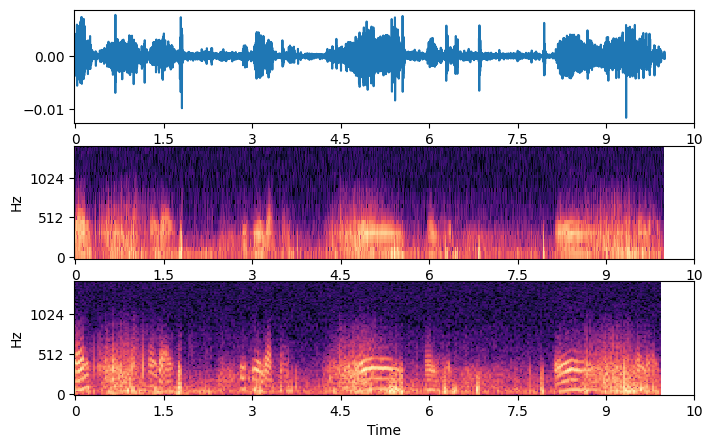

In [36]:
# Applying MFCC analysis on a windowed basis

dataFolder = "Samples"

data_files = os.listdir(dataFolder)
data_files.sort()
#data_files = ['Eko_p005_t01_severe_pos_U_stance_U_20250605.wav']
data_files = ['Eko_p007_t01_severe_20250605.wav']


for data_file in data_files:

    #if not a wav file, skip
    if ".wav" not in data_file:
        continue
    
    print(data_file)

    # path
    wavFilepath = f"{dataFolder}/{data_file}"

    userName, userTest, userSeverity = wav_utils.getTestInfo(data_file)

    # load data
    raw_audio, sample_rate = librosa.load(path=wavFilepath, sr=4000)

    # Noise reduction method, filter
    filter_lowcut = 80
    filter_highcut = 1800
    filter_order = 8
    filter_btype = "bandpass"  
    filt_audio = wav_utils.filter_denoise(raw_audio, sample_rate, filter_order,
                                    filter_lowcut, filter_highcut, btype=filter_btype)

    raw_audio = raw_audio - np.mean(raw_audio)  # Remove DC
    filt_audio = filt_audio - np.mean(filt_audio)  # Remove DC

    #just showing first 10 seconds

    filt_audio = filt_audio[:(sample_rate*10)]

    # Normalise and remove DC component in signal
    x = wav_utils.dc_normalise(filt_audio)
    t = np.arange(len(filt_audio))*(1/sample_rate)

    fig = plt.figure(figsize=(8,5))
    axRaw = fig.add_subplot(311)
    axNarrow = fig.add_subplot(312,sharex=axRaw)
    axWide = fig.add_subplot(313,sharex=axRaw)
    
    axRaw.plot(t,filt_audio)
    
    plot_mel_spectrogram(x, axNarrow, sample_rate, n_mels=32, f_min=50, f_max=1800, winLength = 64, hop=32, show_function=True)
    plot_mel_spectrogram(x, axWide, sample_rate, n_mels=128, f_min=50, f_max=1800, winLength = 256, hop=128, show_function=True)

    plt.show()

   


In [30]:
256/4000

0.064